In [24]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 

In [25]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

### Define results directory

In [26]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/clean/lanczos/diffusion/2022_12_05_03_20_21/standardize/'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/clean/lanczos/encoder/2022_12_05_03_20_21/standardize/'


### Plot Train, Test Loss

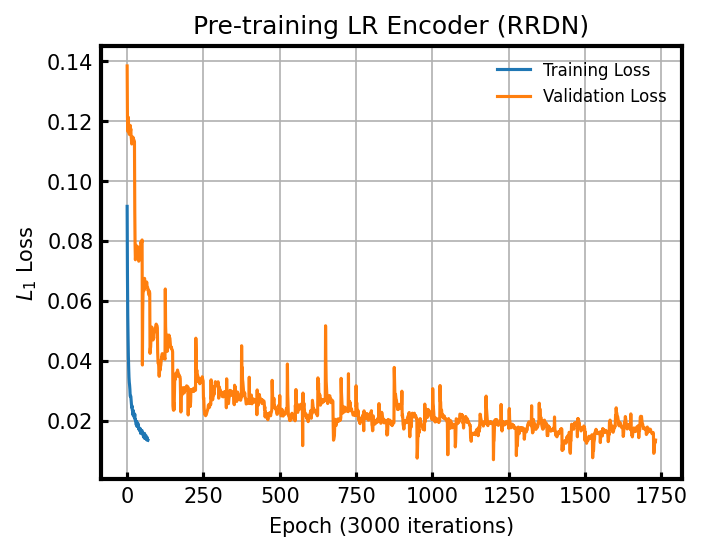

In [38]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'test_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[1:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Pre-training LR Encoder (RRDN)')
plt.grid(which = 'major')
frame_tick()

In [39]:
image_size = 80
channels = 1
batch_size = 4

In [40]:

batch_size = 4
# # load dataset from the hub
from datasets.dataset import TemperatureXZDataset


# os.makedirs(os.path.join(results_dir, 'processed figures'), exist_ok = True)
train_dataset = TemperatureXZDataset(method = 'lanczos', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
test_dataset = TemperatureXZDataset(method ='lanczos', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
dev_dataset = TemperatureXZDataset(method = 'lanczos', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

std_lr =  train_dataset.std_lr
mean_lr = train_dataset.mean_lr  
std_resid =  train_dataset.std_resid
mean_resid =  train_dataset.mean_resid
mean = train_dataset.mean_hr 
std = train_dataset.std_hr

len data: 3044
len data: 609
len data: 406


In [30]:
# np.load(lr_paths[0]).shape
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "2"
# def train_epoch(model, data_loader, criterion, optimizer, epoch = 0, image_dir = ''):
device = 'cuda'
criterion = torch.nn.L1Loss()
data_loader = dataloader
learning_rate = 1e-4
modeltype = 'diffusion'


device = 'cuda'
lr_enc = rrdbnet_x4(num_blocks = 8)

lr_enc.to(device)
learning_rate = 5e-5
lr_encoptimizer = torch.optim.Adam(lr_enc.parameters(), lr=learning_rate,weight_decay = 0)
lrenc_fname = os.path.join(encoder_results_dir, 'model_saved.pth')
lrenc_checkpoint = torch.load(lrenc_fname)
lr_enc.load_state_dict(lrenc_checkpoint['model_state_dict'])
lr_encoptimizer.load_state_dict(lrenc_checkpoint['optimizer_state_dict'])
# epoch = lrenc_checkpoint['epoch']
# loss = lrenc_checkpoint['loss']
lr_enc.eval()
if modeltype == 'diffusion':
    image_size = 80
    # results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_04_11_32_01/standardize'
    image_size = 80
    channels = 1
    batch_size = 4
    model = Unet(
        dim=image_size,
        channels=channels,
        dim_mults=(1, 2, 4,)
    )

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
    from torch.optim.lr_scheduler import StepLR
    scheduler= StepLR(optimizer, step_size = 10, gamma = 0.5)
    # %% [markdown]
    # Let's start training!

    model_fname = os.path.join(diffusion_results_dir, 'ckpt.pth')
    model_checkpoint = torch.load(model_fname)
    model.load_state_dict(model_checkpoint[0])
    optimizer.load_state_dict(model_checkpoint[1])

    model.eval()

    for param in model.parameters():
        param.requires_grad = False
import torch.nn.functional as F



def forwardpass(lr_enc, sample):
    # x  = lr_enc.conv1(sample)
    # x = lr_enc.trunk(x)
    # x = lr_enc.conv2(x)
    # x = F.interpolate(x, scale_factor = 2, mode= 'nearest')
    # x = lr_enc.upsampling1(x)
    # x= F.interpolate(x, scale_factor = 2, mode = 'nearest')
    # x = lr_enc.upsampling2(x)
    # x = lr_enc.conv3(x)
    # x = lr_enc.conv4(x)
    # breakpoint()

    out1 = lr_enc.conv1(sample)
    out = lr_enc.trunk(out1)
    out2 = lr_enc.conv2(out)
    out = torch.add(out1, out2)

    if lr_enc.upscale_factor == 2:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
    if lr_enc.upscale_factor == 4:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling2(F.interpolate(out, scale_factor=2, mode="nearest"))
    if lr_enc.upscale_factor == 8:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling2(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling3(F.interpolate(out, scale_factor=2, mode="nearest"))

    out = lr_enc.conv3(out)
    out = lr_enc.conv4(out)
    return out
for param in lr_enc.parameters():
    param.requires_grad = False



In [31]:
lr_enc

RRDBNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (trunk): Sequential(
    (0): _ResidualResidualDenseBlock(
      (rdb1): _ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (leaky_relu): LeakyReLU(negative_slope=0.2, inplace=True)
        (identity): Identity()
      )
      (rdb2): _ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (co

In [32]:
from models.mobilenet_model import MobileNetv2_SISR

device = 'cuda'
mobilenet = MobileNetv2_SISR()

mobilenet.to(device)
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runners/runs/clean/lanczos/mobilenet/2022_12_05_10_23_02'
mobilenetoptimizer = torch.optim.Adam(mobilenet.parameters(), lr=learning_rate,weight_decay = 0)
mobilenet_fname = os.path.join(mobilenet_results_dir, 'SISR_mv2f.pth')
mobilenet_checkpoint = torch.load(mobilenet_fname)
mobilenet.load_state_dict(mobilenet_checkpoint['model_state_dict'])
mobilenetoptimizer.load_state_dict(mobilenet_checkpoint['optimizer_state_dict'])
# epoch = lrenc_checkpoint['epoch']
# loss = lrenc_checkpoint['loss']
mobilenet.eval()

MobileNetv2_SISR(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (bottlenecks1): Sequential(
    (0): InvertedResidual(
      (conv): Sequential(
        (0): ConvBNReLU(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.01, inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): ConvBNReLU(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (

In [41]:
device = 'cuda'
batch_size = 1
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

res, hr, lr, upscaled_lr =  iter(dataloader).next()
def predict_lrenc(model, res, hr, lr, upscaled_lr, dataset):
    # take in all 4
    # return rescaled input, result, target
    img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))#- 293)/(8000- 293)
    target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))#- 293)/(8000- 293)
    x_e = lr_enc(img.float())
    # x_e = forwardpass(lr_enc, img.float())
    result = x_e.cpu().detach().numpy()[:,0]
    return dataset.unscale_data(lr, input_type='lr'), dataset.unscale_data(x_e.detach().cpu(), input_type = 'hr'), dataset.unscale_data(target.cpu(), input_type = 'hr')
input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)

In [34]:
def predict_mobilenet(model, res, hr, lr, upscaled_lr, dataset):
    img = upscaled_lr.view(upscaled_lr.shape[0], 1, upscaled_lr.shape[1], upscaled_lr.shape[2])
    target = hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2])
    img = img.to(device)
    target = target.to(device)
    
    output = model(img)
    return dataset.unscale_data(lr, input_type='lr'), dataset.unscale_data(output.detach().cpu(), input_type = 'hr'), dataset.unscale_data(target.cpu(), input_type = 'hr') 


In [35]:
device = 'cuda'
batch_size = 1
from runners.train_diffusion import forwardpass, sample, num_to_groups
# dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# res, hr, lr, upscaled_lr =  iter(dataloader).next()
def predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, timesteps = 200):
    # take in all 4
    # return rescaled input, result, target
    img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
    target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
    batches = num_to_groups(1, batch_size)
    print(timesteps, batches, img.shape[0])
    all_images_list = list(map(lambda n: sample(model, x_e = x_e, timesteps = timesteps, image_size = 80,  batch_size=img.shape[0], channels=channels), batches))[0]
    all_images = torch.stack(all_images_list, dim=0)
    result = train_dataset.unscale_data(all_images.numpy()[-1, 0], input_type = 'residual') + train_dataset.unscale_data(upscaled_lr.numpy(), input_type = 'upscaled_lr')
    
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')
# input, result, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)

In [36]:
def plot_images(input, result, target, modeltype, split = 'train'):
    
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 5000
    method = 'Direct'

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow(input.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((target).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    plt.show()

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((result).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] {} Output'.format(split, modeltype), fontsize = 10)
    plt.show()


def get_profile(image, mesh = 5):
    image = image[0].T
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [37]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    # input, lr_enc_result, target = predict_diffusion(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)

    plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Test', modeltype = "Encoder")
    plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Test', modeltype = "MobileNetSISR")

    plot_images(input[0], result_diffusion[0], target[0][0], split = 'Test', modeltype = "Diffusion")
    


torch.Size([4, 20, 20])
200 [1] 4


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

/home/oogoke/DiffusionSR/models/diffusion_model.py:284: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(x,dtype=torch.float)


KeyboardInterrupt: 

In [ ]:
result_diffusion.shape
lr_enc_result.shape

In [ ]:
kp_depth_diff

[-300,
 -920,
 -440,
 -1180,
 -980,
 -700,
 -640,
 -1000,
 -640,
 -1160,
 -380,
 -940,
 -620,
 -880,
 -820,
 -540,
 -680,
 -1180,
 -840,
 -800,
 -580,
 -1040,
 -980,
 -1020,
 -1000,
 -980,
 -940,
 -380,
 -760,
 -940,
 -1100,
 -720,
 -660,
 -1060,
 -520,
 -220,
 -1180,
 -300,
 -800,
 -60,
 -1060,
 -440,
 -480,
 -680,
 -1180,
 -1180,
 -1020,
 -500,
 -1020,
 -600,
 -200,
 -1000,
 -1180,
 -960,
 -1080,
 -1000,
 -660,
 -620,
 -680,
 -600,
 -300,
 -580,
 -820,
 -760,
 -720,
 -960,
 -540,
 -980]

In [42]:
max_depth_enc = []
max_depth_diff = []
max_depth_mbn = []

max_depth_gt = []
max_depth_input = []
kp_depth_enc = []
kp_depth_diff = []
kp_depth_mbn = []

kp_depth_gt = []
kp_depth_input = []
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)

    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet, res, hr, lr, upscaled_lr, dev_dataset)


    profile_enc, kp_enc = get_profile(lr_enc_result)
    profile_diff, kp_diff = get_profile(result_diffusion)
    profile_mbn, kp_mbn = get_profile(result_mobilenet)
    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)
    max_depth_enc.append(5*(80-np.min(profile_enc)))
    max_depth_gt.append(5*(80-np.min(profile_gt)))
    max_depth_diff.append(5*(80-np.min(profile_diff)))
    max_depth_mbn.append(5*(80-np.min(profile_mbn)))

    max_depth_input.append(20*(20-np.min(profile_input)))
    kp_depth_enc.append(5*(80-np.min(kp_enc)))
    kp_depth_gt.append(5*(80-np.min(kp_gt)))
    kp_depth_input.append(20*(20-np.min(kp_input)))
    kp_depth_diff.append(5*(80-np.min(kp_diff)))
    kp_depth_mbn.append(5*(80-np.min(kp_mbn)))

    # print(20*(20-np.min(profile_input)))

200 [1] 4


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4


...

sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

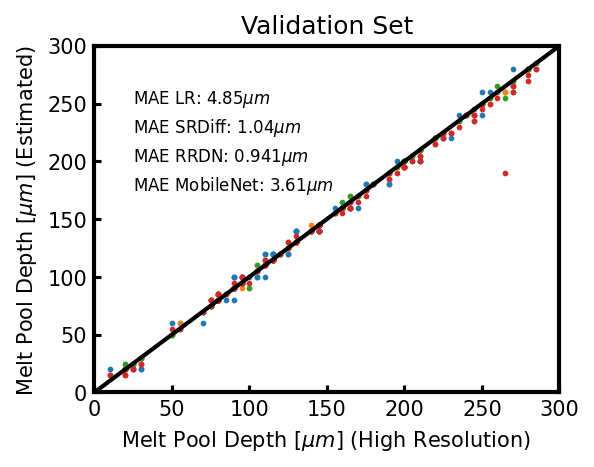

In [44]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth_diff)
mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)



# plt.plot(np.arange(300),np.arange(300)-2.27, 'k--', linewidth = 2.0)
# plt.plot(np.arange(300),np.arange(300)+2.27, 'k--', linewidth = 2.0)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )


# legend(location = 'lower right')
    
plt.show()

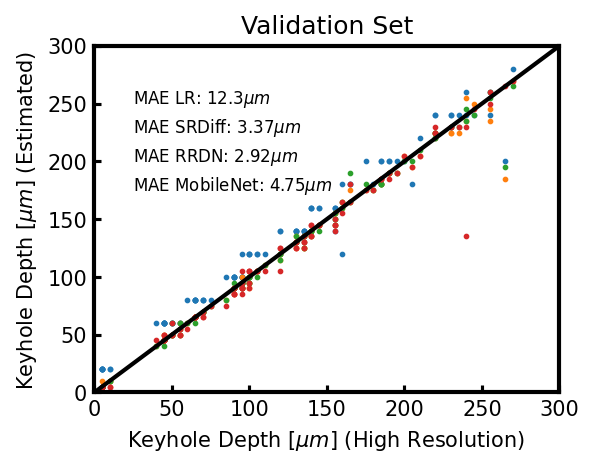

In [45]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)
mae_depth_mbn = mean_absolute_error(kp_depth_gt, kp_depth_mbn)



# plt.plot(np.arange(300),np.arange(300)-2.27, 'k--', linewidth = 2.0)
# plt.plot(np.arange(300),np.arange(300)+2.27, 'k--', linewidth = 2.0)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )


# legend(location = 'lower right')
    
plt.show()

In [ ]:
kp_depth_diff

[-300,
 -920,
 -440,
 -1180,
 -980,
 -700,
 -640,
 -1000,
 -640,
 -1160,
 -380,
 -940,
 -620,
 -880,
 -820,
 -540,
 -680,
 -1180,
 -840,
 -800,
 -580,
 -1040,
 -980,
 -1020,
 -1000,
 -980,
 -940,
 -380,
 -760,
 -940,
 -1100,
 -720,
 -660,
 -1060,
 -520,
 -220,
 -1180,
 -300,
 -800,
 -60,
 -1060,
 -440,
 -480,
 -680,
 -1180,
 -1180,
 -1020,
 -500,
 -1020,
 -600,
 -200,
 -1000,
 -1180,
 -960,
 -1080,
 -1000,
 -660,
 -620,
 -680,
 -600,
 -300,
 -580,
 -820,
 -760,
 -720,
 -960,
 -540,
 -980]

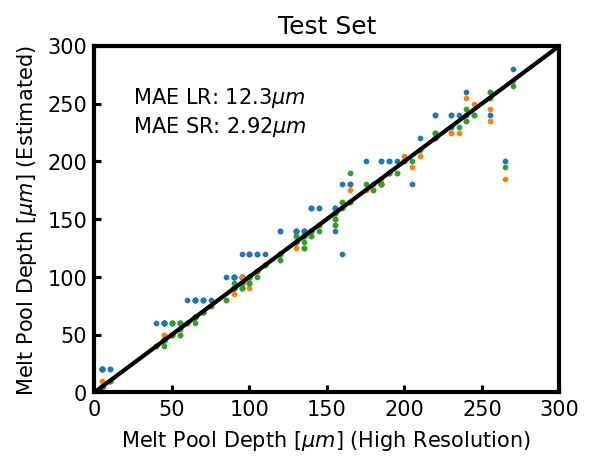

In [46]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_enc)


# plt.plot(np.arange(300),np.arange(300)-2.27, 'k--', linewidth = 2.0)
# plt.plot(np.arange(300),np.arange(300)+2.27, 'k--', linewidth = 2.0)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
# legend(location = 'lower right')
    
plt.show()

In [ ]:
def plot_temp_lines(input, result, target, modeltype, split = 'train'):
  
   
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'


    # dpi = 150
    # scaling_factor = 1.5
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
# max_temp = 5000
# min_temp = 293
# dpi = 90
# scaling_factor = 1.5
# method = 'Lanczos'
plot_temp_lines(input, result_diffusion[0], target[0][0], split = 'test', modeltype = "Diffusion")
plot_temp_lines(input, lr_enc_result[0][0], target[0][0], split = 'test', modeltype = "Encoder")


In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):
    print(result.shape)
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    # plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    # plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()
input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
# input, lr_enc_result, target = predict_diffusion(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
print(input.shape)
input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)
input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, train_dataset)
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion")
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder")
plot_srdiff_contours(input, result_mobilenet, target[0], split = 'Train', modeltype = "MobileNet")


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")

plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")
# plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):

In [ ]:
# plt.imshow(result_diffusion[0] > 1700)
profile_result, kp_result = get_profile(result_diffusion)
profile_mbn_result, kp_mbn_result = get_profile(result_mobilenet)
profile_enc_result, kp_enc_result = get_profile(lr_enc_result)
plt.step(5*np.arange(80), profile_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_enc_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_mbn_result - 400, label = 'Super Resolution (Output)' )


In [ ]:
profile_result

In [ ]:
parent_directory = '/home/oogoke/SRdataset/epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
epoch = 148
data_1 = np.load(os.path.join(parent_directory, 'all_data-{}.npz').format(epoch))


In [ ]:
from mobilenet_model import MobileNetv2_SISR, test_predictions, train_epoch, dev_epoch

device = 'cuda'
mobilenet = MobileNetv2_SISR()

mobilenet.to(device)
results_dir = '/home/oogoke/runs/clean/lanczos/mobilenet/2022_11_27_22_55_08'
mobilenetoptimizer = torch.optim.Adam(mobilenet.parameters(), lr=learning_rate,weight_decay = 0)
mobilenet_fname = os.path.join(results_dir, 'model_final.pth')
mobilenet_checkpoint = torch.load(mobilenet_fname)
mobilenet.load_state_dict(mobilenet_checkpoint['model_state_dict'])
mobilenetoptimizer.load_state_dict(mobilenet_checkpoint['optimizer_state_dict'])
# epoch = lrenc_checkpoint['epoch']
# loss = lrenc_checkpoint['loss']
mobilenet.eval()
import torch.nn.functional as F

In [ ]:
for batch_num, (res, hr, true_lr, upscaled_lr) in tqdm(enumerate(data_loader), total=len(data_loader), ascii=True):

    # if np.random.random() > 0.5:
    #     #flip both img and target

    #     img = torch.flip(img, dims = [2])#[0][0]#torch.flip(img, dims =0)
    #     target =torch.flip(target, dims = [2])#[0][0]  #torch.flip(target, dims =0)
    
    img = upscaled_lr.view(upscaled_lr.shape[0], 1, upscaled_lr.shape[1], upscaled_lr.shape[2])
    target = hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2])
    img = img.to(device)
    target = target.to(device)
    
    output = mobilenet(img)
    new_out = output#*(8000-293) + 293
    break

In [ ]:
plt.imshow(new_out.detach().cpu().numpy()[0][0]*std+mean, cmap = 'jet', origin = 'lower')

In [ ]:
std_resid = data_1['std_resid']
mean_resid = data_1['mean_resid']
std_lrs = data_1['std_lrs']
mean_lrs = data_1['mean_lrs']
sampled_data = data_1['sampled']
lr_data = data_1['upscaled_lr']
input_data = data_1['true_lr']
residuals = sampled_data[:,0]*std_resid + mean_resid

true_residual = data_1['res']*std_resid + mean_resid
true_lrs = input_data*std_lrs + mean_lrs
hr = data_1['hr']
generated_hr = lr_data + residuals

In [ ]:
plt.imshow(data_1['upscaled_lr'][0])
plt.show()
plt.imshow(data_1['true_lr'][0])
plt.show()
plt.imshow(data_1['hr'][0])
plt.show()
plt.imshow(data_1['res'][0])
plt.show()
for i in range(16):
    plt.title(i)
    plt.imshow(data_1['sampled'][i,0])
    plt.show()

In [ ]:
def plot_temp_images_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):
# max_temp = 5000
# min_temp = 293
# dpi = 90
# scaling_factor = 1.5
# method = 'Lanczos'

    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow((true_lrs[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Low Resolution, {} downscaling'.format('Train', method), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((hr[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] High Resolution'.format('Train'), fontsize = 10)
    plt.show()


    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((residuals[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, Sampled'.format('Train'), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((true_residual[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, GT'.format('Train'), fontsize = 10)
    plt.show()

In [ ]:
def plot_temp_lines_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):

    std_resid = data_1['std_resid']
    mean_resid = data_1['mean_resid']
    std_lrs = data_1['std_lrs']
    mean_lrs = data_1['mean_lrs']
    sampled_data = data_1['sampled']
    lr_data = data_1['upscaled_lr']
    input_data = data_1['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data_1['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data_1['hr']
    generated_hr = lr_data + residuals
    # dpi = 150
    # scaling_factor = 1.5
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.title(r'SRDiff model, Cross section: x = 200 $\mu m$')
    plt.plot(80*5*(np.arange(true_lrs.shape[2])/true_lrs.shape[2]),true_lrs[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),hr[0][40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),generated_hr[0][40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()

In [ ]:
def get_keyhole_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.max(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)

def get_mp_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.min(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)


In [ ]:
def plot_srdiff_contours(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos', split = 'Train'):
    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    

    residuals = sampled_data[:,0]*std_resid + mean_resid
    generated_hr = lr_data + residuals
    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']
    profile = get_keyhole_profile(generated_hr)
    profile_gt = get_keyhole_profile(hr)
    profile_input = get_keyhole_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Keyhole Depth'.format('Train'), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')


    profile = get_mp_profile(generated_hr)
    profile_gt = get_mp_profile(hr)
    profile_input = get_mp_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Melt Pool Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')

In [ ]:
def plot_lrenc_contours(split = 'Train'):
    if split == 'Train':
        img, target, result = predict(dataloader)
    elif split == 'Test': 
        img, target, result = predict(dev_dataloader)

    std_lrs = train_dataset.std_lr
    mean_lrs = train_dataset.mean_lr
    lr_data =  img[:,0].cpu().detach().numpy()
    input_data = img[:,0].cpu().detach().numpy()
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'All'

    generated_hr = result*train_dataset.std_hr + train_dataset.mean_hr
    hr = target[:,0]*train_dataset.std_hr + train_dataset.mean_hr
    
    true_lrs = input_data*std_lr + mean_lr

    profile = get_keyhole_profile(generated_hr)
    profile_gt = get_keyhole_profile(hr)
    profile_input = get_keyhole_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    plt.xlim([0, 400])

    legend()
    plt.title('[{} Data] Keyhole Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')


    profile = get_mp_profile(generated_hr)
    profile_gt = get_mp_profile(hr)
    profile_input = get_mp_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    plt.xlim([0, 400])
    legend()
    plt.title('[{} Data] Melt Pool Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
plot_lrenc_contours(split ='Train')

In [ ]:
for epoch in range(140, 150, 2):
    parent_directory = '/home/oogoke/SRdataset/epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
    data_1 = np.load(os.path.join(parent_directory, 'all_data-{}.npz').format(epoch))
    plot_temp_images_srdiff(data_1)
    plot_temp_lines_srdiff(data_1)
    plot_srdiff_contours(data_1)



In [ ]:
def PSNR(op, t, batch_size): 
    mse = torch.sum((t - op) ** 2) 
    #print(mse.size())
    mse /= (batch_size*80*80)

    max_pixel = torch.max(t)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    #print(psnr.size())
    return psnr 
# print('LR PSNR: ', PSNR(lr_data, hr, hr.shape[0]))
# print('HR PSNR: ',PSNR(generated_hr, hr, hr.shape[0]))


In [ ]:
nn.L1Loss()(lr_enc_result, target)


tensor(29.5040, dtype=torch.float64)

In [ ]:
lrpsnrs = []
lrencpsnrs = []
diffpsnrs = []
mobilenetpsnrs = []
lrl1loss = []
lrencl1loss = []
diffl1loss = []
mobilenetl1loss= []

l1loss = nn.L1Loss()
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    # input, lr_enc_result, target = predict_diffusion(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)
        # plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
        # plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")

        # plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()
    lrencpsnr = PSNR(lr_enc_result, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()

    mobilenetpsnr = PSNR(result_mobilenet, target, target.shape[0]).item()

    print('LR PSNR: ', lrpsnr)
    print('LR enc PSNR: ',PSNR(lr_enc_result, target, target.shape[0])) 
    print('Diffusion PSNR: ',PSNR(result_diffusion, target, target.shape[0])) 
    print('MobileNet PSNR: ',PSNR(result_mobilenet, target, target.shape[0])) 
    (lr_enc_result, target)
    lrpsnrs.append(lrpsnr)
    lrencpsnrs.append(lrencpsnrs)
    diffpsnrs.append(diffpsnr)
    mobilenetpsnrs.append(mobilenetpsnr)
    lrl1loss.append(l1loss(upscale, target[:,0]).item())
    lrencl1loss.append(l1loss(lr_enc_result[:,0], target[:,0]).item())
    diffl1loss.append(l1loss(torch.tensor(result_diffusion), target[:,0]).item())
    mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())




NameError: name 'predict_lrenc' is not defined

In [ ]:
np.mean(lrpsnrs)


14.002704988777554

In [ ]:
np.mean(lrencpsnrs)


In [ ]:
np.mean(mobilenetpsnr)


In [ ]:
np.mean(diffpsnrs)


In [ ]:
result_mobilenet.shape
# result_diffusion

torch.Size([4, 1, 80, 80])

In [1]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))



NameError: name 'lr_data' is not defined